In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw02B.ipynb")

# 🕵️ Homework 2B: Food Safety (Continued)

## ‼️ Due Date: Friday, February 13, 11:59 PM
You must submit this assignment to Pensive by the on-time deadline, Friday, February 13, 11:59 PM. Please read the syllabus for the Slip Day policy. No late submissions beyond the details in the Slip Day policy will be accepted. While course staff is happy to help you if you encounter difficulties with submission, we may not be able to respond to late-night requests for assistance (TAs need to sleep, after all!). **We strongly encourage you to plan to submit your work to Pensive several hours before the stated deadline.** This way, you will have ample time to contact staff for submission support. 

Please read the instructions carefully when you are submitting your work to Pensive.

## 💪 Collaboration Policy

Data science is a collaborative activity. While you may talk with others about the homework, we ask that you **write your solutions individually**. If you do discuss the assignments with others, please **include their names** below.

**Collaborators**: *list collaborators here*


## 📜 This Assignment

In this homework, we will continue our exploration of restaurant food safety scores for restaurants in San Francisco. The main goal for this assignment is to focus more on the analysis of the dataset, building on the data cleaning we have done earlier in HW 2A. 


After this homework, you should be comfortable with:
* Reading `pandas` documentation and using `pandas` methods,
* Working with data at different levels of granularity,
* Using `groupby` with different aggregation functions, and
* Chaining different `pandas` functions and methods to find answers to exploratory questions.


## 💯 Score Breakdown 
Question | Manual | Points
--- | --- | ---
1a | no | 2
1b | no | 3
1c | no | 3
2a | no | 2
2b | no | 3
3a | yes | 3
3b | yes | 3
4a | no | 2
4b | no | 3
4c | no | 3
4d | yes | 1
5 | yes | 2
Total | 4 | 30


## ✊ Before You Start

For each question in the assignment, please write down your answer in the answer cell(s) right below the question. 

We understand that it is helpful to have extra cells breaking down the process towards reaching your final answer. If you happen to create new cells below your answer to run code, **NEVER** add cells between a question cell and the answer cell below it. It will cause errors when we run the autograder, and it will sometimes cause a failure to generate the PDF file.

**Important note: The local autograder tests will not be comprehensive. You can pass the automated tests in your notebook but still fail tests in the autograder.** Please be sure to check your results carefully.

Finally, unless we state otherwise, **do not use for loops or list comprehensions**. The majority of this assignment can be done using built-in commands in `pandas` and `NumPy`. Our autograder isn't smart enough to check, but you're depriving yourself of key learning objectives if you write loops / comprehensions, and you also won't be ready for the midterm.

### 🐛 Debugging Guide
If you run into any technical issues, we highly recommend checking out the [Data 100 Debugging Guide](https://ds100.org/debugging-guide/). In this guide, you can find general questions about Jupyter notebooks / Datahub, Pensive, and common `pandas` errors.

In [2]:
import numpy as np
import pandas as pd

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

In HW 2A, we took you through the entire process of reading data from a file to perform some exploration of the data. Here, we again load the dataset that we will be using in HW 2B along with some of the columns we had added in HW 2A. For any additional context regarding the dataset, we encourage you to revisit HW 2A.

In [3]:
bus = pd.read_csv('data/bus.csv', encoding='ISO-8859-1').rename(columns={"business id column": "bid"})
bus['postal5'] = bus['postal_code'].str[:5]
valid_zip_codes = pd.read_json("data/sf_zipcodes.json")['zip_codes'].astype("string")
bus = bus[bus['postal_code'].isin(valid_zip_codes)]

ins = pd.read_csv('data/ins.csv')
ins['timestamp'] = pd.to_datetime(ins['date'], format='%m/%d/%Y %I:%M:%S %p')
ins['bid'] = ins['iid'].str.split("_", expand=True)[0].astype(int) 

# This code is essential for the autograder to function properly. Do not edit.
ins_test = ins

<br/>

---

# 🔎 Question 1: Inspecting the Inspections

## 🚀 Question 1a

Let's start by looking again at the first 5 rows of `ins` to see what we're working with.

In [4]:
ins.head(5)

,iid,date,score,type,timestamp,bid
0,100010_20190329,03/29/2019 12:00:00 AM,-1,New Construction,2019-03-29,100010
1,100010_20190403,04/03/2019 12:00:00 AM,100,Routine - Unscheduled,2019-04-03,100010
2,100017_20190417,04/17/2019 12:00:00 AM,-1,New Ownership,2019-04-17,100017
3,100017_20190816,08/16/2019 12:00:00 AM,91,Routine - Unscheduled,2019-08-16,100017
4,100017_20190826,08/26/2019 12:00:00 AM,-1,Reinspection/Followup,2019-08-26,100017


To better understand how the scores have been allocated, let's examine how the maximum score varies for each type of inspection. 

Create a `DataFrame` object `ins_score_by_type`, indexed by all the inspection types (e.g., New Construction, Routine - Unscheduled, etc.), with a single column named `max_score` containing the highest score received. Additionally, order `ins_score_by_type` by `max_score` in descending order. 

**Hint:** You may find the `rename` ([documentation](https://pandas.pydata.org/pandas-docs/version/2.3/reference/api/pandas.DataFrame.rename.html)) to be useful! 

In [5]:
ins_score_by_type = ins.groupby('type')['score'].idxmax()
ins_score_by_type = ins.loc[ins_score_by_type, ['type', 'score']]
ins_score_by_type = (
    ins_score_by_type.sort_values('score', ascending=False)
                     .rename(columns={'score': 'max_score'})
                     .set_index('type')
)
                        
ins_score_by_type

,max_score
type,
Routine - Unscheduled,100
Community Health Assessment,-1
Administrative or Document Review,-1
Complaint Reinspection/Followup,-1
Foodborne Illness Investigation,-1
Multi-agency Investigation,-1
Complaint,-1
New Construction,-1
New Ownership,-1


In [6]:
grader.check("q1a")

q1a results: All test cases passed!

<br/>

---

## 🚀 Question 1b


Given the variability of `ins['score']` observed in 1a, let's examine the inspection scores `ins['score']` further.

In [7]:
ins['score'].value_counts().head()

score
-1      12632
 100     1993
 96      1681
 92      1260
 94      1250
Name: count, dtype: int64

There are a large number of inspections with a score of -1. These are probably missing values. Let's see what types of inspections have scores and which do not (score of -1). 

- First, define a new column `Missing Score` in `ins` where each row maps to the string `"Yes"` if the `score` for that business is -1 and `"No"` otherwise. 

- Then, use `groupby` to find the number of inspections for every combination of `type` and `Missing Score`. Store these values in a new column `Count`. 

- Finally, sort `ins_missing_score_group` by descending `Count`s. 
The result should be a `DataFrame` that looks like the one shown below.

**Hint**: You may find the `map` ([documentation](https://pandas.pydata.org/pandas-docs/version/2.3/reference/api/pandas.DataFrame.map.html)) useful for defining `Missing Score`! 

**Note:** Again, as mentioned in Lab 2B, if you define the `agg_func` in any problem that involves `pivot_table` or `agg` in any problem that involves `groupBy`, you might encounter the following error: <br>

`FutureWarning: The provided callable <built-in function (the function that you want to use)> is currently using DataFrameGroupBy.(the function you want to use). In a future version of pandas, the provided callable will be used directly. To keep current behavior, pass the string (the function you want to use) instead.`

Do not panic! You can safely ignore this message for this semester. However, if you would like to avoid seeing the warning entirely, follow the instructions provided in the warning and pass the string version of the function you want to use instead. For example, if you want to use `np.min`, write `"min"` instead of `np.min`.

<table border="1" class="dataframe" >  <thead>    
    <tr style="text-align: right;">      <th></th>      <th></th>      <th>Count</th>   </tr>
    <tr style="text-align: right;">      <th>type</th>      <th>Missing Score</th>      <th></th>   </tr>    <tr align="right"> <tbody>    
    <tr  align="right">      <th>Routine - Unscheduled</th>      <th>No</th>      <td>14031</td>         </tr>    
    <tr  align="right">      <th>...</th>      <td>...</td>      <td>...</td>        </tr>    
    <tr  align="right">      <th>...</th>      <td>...</td>      <td>...</td>       </tr>    </tbody> </table>

In [8]:
def is_missing(row):
    return 'Yes' if row == -1 else 'No'
ins['Missing Score'] = ins['score'].map(is_missing)
ins_missing_score_group = (
    ins.groupby(['type', 'Missing Score'])
    .size()
    .reset_index(name='Count')
    .set_index(['type', 'Missing Score'])
)
ins_missing_score_group = ins_missing_score_group.sort_values('Count', ascending=False)

ins_missing_score_group

,,Count
type,Missing Score,
Routine - Unscheduled,No,14031
Reinspection/Followup,Yes,6439
New Ownership,Yes,1592
Complaint,Yes,1458
New Construction,Yes,994
Non-inspection site visit,Yes,811
New Ownership - Followup,Yes,499
Structural Inspection,Yes,394
Complaint Reinspection/Followup,Yes,227


In [9]:
...


Ellipsis

In [10]:
grader.check("q1b")

q1b results: All test cases passed!

<br/>

---

## 🚀 Question 1c


Using `groupby` to perform the analysis above gave us a `DataFrame` that wasn't the most readable at first glance. There are better ways to represent the information above that take advantage of the fact that we are looking at combinations of two variables. It's time to pivot (pun intended)!

Create a `DataFrame` that looks like the one below, and assign it to the variable `ins_missing_score_pivot`. 

You'll want to use the `pivot_table` method of the `DataFrame` class, which you can read about in the `pivot_table` [documentation](https://pandas.pydata.org/pandas-docs/version/2.3/reference/api/pandas.DataFrame.pivot_table.html). 

- Once you create `ins_missing_score_pivot`, add another column titled `Proportion Missing`, which contains the proportion of missing scores within each `type`. 

- Then, sort `ins_missing_score_pivot` in descending order of `Proportion Missing`. Reassign the sorted `DataFrame` back to `ins_missing_score_pivot`.

**Hint:** Consider what happens if no values correspond to a particular combination of `Missing Score` and `type`. Looking at the documentation for `pivot_table`, is there any function argument that allows you to specify what value to fill in?

If you've done everything right, you should observe that inspection scores appear only to be assigned to `Routine - Unscheduled` inspections and that `ins_missing_score_pivot` looks like the `DataFrame` below:


<table border="1" class="dataframe" >  <thead>    
    <tr style="text-align: right;">      <th>Missing Score</th>      <th>No</th>      <th>Yes</th>      <th>Proportion Missing</th>    </tr>    <tr style="text-align: right;">      <th>type</th>      <th></th>      <th></th>      <th></th>    </tr>  </thead>  <tbody>    
    <tr  align="right">      <th>Administrative or Document Review</th>      <td>0</td>      <td>4</td>      <td>1.000000</td>    </tr>    
    <tr  align="right">      <th>...</th>      <td>...</td>      <td>...</td>      <td>...</td>    </tr>    
    </tbody></table>


In [11]:
ins_missing_score_pivot = ins.pivot_table(
    index='type',
    columns='Missing Score',
    values='iid',
    aggfunc='size',
    fill_value=0
)
ins_missing_score_pivot['Proportion Missing'] = ins_missing_score_pivot['Yes'] / (ins_missing_score_pivot['Yes'] + ins_missing_score_pivot['No'])

...

ins_missing_score_pivot

Missing Score,No,Yes,Proportion Missing
type,,,
Administrative or Document Review,0,4,1.000000
Community Health Assessment,0,1,1.000000
Complaint,0,1458,1.000000
Complaint Reinspection/Followup,0,227,1.000000
Foodborne Illness Investigation,0,115,1.000000
Multi-agency Investigation,0,3,1.000000
New Construction,0,994,1.000000
New Ownership,0,1592,1.000000
New Ownership - Followup,0,499,1.000000


In [12]:
grader.check("q1c")

q1c results: All test cases passed!

It is reasonable for inspection types such as `New Ownership` and `Complaint` to have no associated inspection scores, but you might be curious why there are no inspection scores for the `Reinspection/Followup` inspection type. Later in the HW, we will examine these `Reinspection/Followup` inspections.

<br/>

---

# 🚀 Question 2: Joining Data Across Tables

In this question, we will start to connect data across multiple tables. We will be using the `pd.merge` function. 

<br/>

--- 

## 🚀 Question 2a

Let's figure out which restaurants had the lowest scores. Before we proceed, filter out missing scores from `ins` so that negative scores don't influence our results. 

In [13]:
ins = ins[ins["score"] > 0]

We'll start by creating a new `DataFrame` called `ins_named`. `ins_named` should be exactly the same as `ins`, except that it should have the name and address of every business, as determined by the `bus` `DataFrame`. 

**Hint**: Use the `DataFrame` method `merge` to join the `ins` `DataFrame` with the appropriate portion of the `bus` `DataFrame`. See the [documentation](https://pandas.pydata.org/pandas-docs/version/2.3/user_guide/merging.html) for guidance on how to use `merge` function to combine two `DataFrame` objects. The first few rows of `ins_named` `DataFrame` are shown below:

<img src="pics/2a.png" width="1080"/>

In [14]:
ins_named = ins.merge(bus[['bid', 'name', 'address']])
...
ins_named.head()

,iid,date,score,type,timestamp,bid,Missing Score,name,address
0,100010_20190403,04/03/2019 12:00:00 AM,100,Routine - Unscheduled,2019-04-03,100010,No,ILLY CAFFE SF_PIER 39,PIER 39 K-106-B
1,100017_20190816,08/16/2019 12:00:00 AM,91,Routine - Unscheduled,2019-08-16,100017,No,AMICI'S EAST COAST PIZZERIA,475 06th St
2,100041_20190520,05/20/2019 12:00:00 AM,83,Routine - Unscheduled,2019-05-20,100041,No,UNCLE LEE CAFE,3608 BALBOA ST
3,100055_20190425,04/25/2019 12:00:00 AM,98,Routine - Unscheduled,2019-04-25,100055,No,Twirl and Dip,335 Martin Luther King Jr. Dr
4,100055_20190912,09/12/2019 12:00:00 AM,82,Routine - Unscheduled,2019-09-12,100055,No,Twirl and Dip,335 Martin Luther King Jr. Dr


In [15]:
grader.check("q2a")

q2a results: All test cases passed!

<br/>

--- 

## 🚀 Question 2b

Look at the 10 businesses in `ins_named` with the lowest scores. Order `ins_named` by each business's minimum score in ascending order. Use the business names in ascending order to break ties. The resulting `DataFrame` should look like the table below.

This one is pretty challenging! Don't forget to rename the `score` column. 

**Hint**: The `agg` function can accept a dictionary as an input. See the `agg` [documentation](https://pandas.pydata.org/pandas-docs/version/2.3/reference/api/pandas.core.groupby.DataFrameGroupBy.agg.html). Additionally, when thinking about what aggregation functions to use, ask yourself: "*What value would be in the `name` column for each entry across the group? Can we select just one of these values to represent the whole group?*"

As usual, **YOU SHOULD NOT USE LOOPS OR LIST COMPREHENSIONS**. Try to break down the problem piece by piece instead, gradually chaining together different `pandas` functions. Feel free to use more than one line!

<table border="1" class="dataframe">  <thead>    
    <tr style="text-align: right;">      <th></th>      <th>name</th>      <th>min score</th>    </tr> 
    <tr  align="right">  <th align="right">bid</th>      <th></th>      <th></th>    </tr> </thead>  <tbody>    
    <tr  align="right">      <th>86718</th>      <td>Lollipot</td>      <td>45</td>    </tr>  
    <tr  align="right">      <th>...</th>      <td>...</td>      <td>...</td>    </tr> 
  </tbody></table>

In [16]:
ten_lowest_scoring = ins_named.groupby('bid').agg({'name': lambda x: x.mode(0), 'score': 'min'}).sort_values(['score', 'name']).head(10)

# DO NOT USE LIST COMPREHENSIONS OR LOOPS OF ANY KIND!!!

...

ten_lowest_scoring

,name,score
bid,,
86718,Lollipot,45
1154,SUNFLOWER RESTAURANT,46
10877,CHINA FIRST INC.,48
67237,La Jefa,51
84590,Chaat Corner,54
71310,Golden King Vietnamese Restaurant,55
91843,Hello Sandwich & Noodle,55
59828,Tip Top Market,55
66961,Mi Tierra Market,57


In [17]:
grader.check("q2b")

q2b results: All test cases passed!

<br/>

---

# 🌮 Question 3: `pandas` Potpourri

In this question, we ask you to describe `pandas` operations and explain specific concepts using `ins_named`.

<!-- BEGIN QUESTION -->

<br/>

---

## 🌮 Question 3a

Consider the chained `pandas` statement below:

`q3a_df = ins_named[ins_named["name"].str.lower().str.contains("taco")].groupby("bid").filter(lambda sf: sf["score"].max() > 95).agg("count")`

We can decompose this statement into three parts:

```
temp1 = ins_named[ins_named["name"].str.lower().str.contains("taco")]
 
temp2 = temp1.groupby("bid").filter(lambda sf: sf["score"].max() > 95)
 
q3a_series = temp2.agg("count")
```

For each line of code above, write one sentence describing what the line of code accomplishes. Feel free to create a cell to see what each line does. In total, you'll write three sentences.

An example answer will look like the following: "`temp1` creates a ... `temp2` transforms `temp1` by ... Finally, `q3a_df` results in a `DataFrame` that ... "

`temp1` creates a dataframe containing all instgram accounts of which name contains "taco" ignoring cases,
`temp2` transform from `temp1` by filtering all business which has at least 95 in "score" grouping by bid,
Finally, `q3a_df` results in a `DataFrame` that count all remaining records grouping by bid.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br/>

---

## 🌮 Question 3b

Consider `temp1`, `temp2`, and `q3a_series` from the previous problem. What is the granularity of each `DataFrame`? Explain your answer in no more than three sentences.

**Note**: For more details on what the granularity of a `DataFrame` means, feel free to check the [course notes](https://ds100.org/course-notes/eda/#granularity)!

`temp1`: the same as `ins_named`, each is an instagram account;

`temp2`: the granularity is not changed, each is an instagram account;

`q3a_series`: each is a business defined by `bid` after aggreration.

<!-- END QUESTION -->

<br/>

---

# 🚀 Question 4: Missing Inspections

With our inspection data, we are given the `type` of each inspection. These categories were lightly investigated in Question 1, centered on the number of missing scores within each `type`. Since the `timestamp` and `score` for each inspection are also provided, we can do a more interesting analysis relating the `score` and `timestamp` of specific types of inspections. 

Specifically, in Question 4, we are interested in the possible relationship between inspections of the `type` "Routine - Unscheduled" and "Reinspection/Followup" (the two most frequent inspection types in our dataset). We might guess that a follow-up ("Reinspection/Followup") inspection occurs more frequently when an initial ("Routine - Unscheduled") inspection receives a low score. To confirm this hunch, let’s investigate the rate of follow-up inspections for different initial scores. To simplify your analysis, we have provided a new `DataFrame` (`reinspections`). 

- `reinspections` contains every "Routine - Unscheduled" inspection, along with the relevant `bid` and `name` associated with the initial inspection. 
- `routine timestamp` indicates when the initial inspection occurred. 
- `routine score` is the score that the initial inspection received. 
- `day difference` is the number of days between the initial inspection and a follow-up inspection if done within one year. 
    
Some initial inspections did not have any follow-up inspections within one year. In these cases, `day difference` is assigned a filler value of -1.

Run the cell below to load in `reinspections`.

In [18]:
reinspections = pd.read_csv('data/reinspections.csv')
reinspections

,bid,routine timestamp,routine score,name,day difference
0,19,2017-12-11,94,Nrgize Lifestyle Cafe,-1.0
1,19,2018-06-07,96,Nrgize Lifestyle Cafe,-1.0
2,24,2016-10-05,98,OMNI S.F. Hotel - 2nd Floor Pantry,-1.0
3,24,2017-11-01,98,OMNI S.F. Hotel - 2nd Floor Pantry,-1.0
4,24,2019-05-01,98,OMNI S.F. Hotel - 2nd Floor Pantry,15.0
...,...,...,...,...,...
14072,101853,2019-09-18,100,INDIAN MARKET AND LIQUOR,-1.0
14073,102067,2019-09-11,100,Humphry Slocombe Ice Cream,-1.0
14074,102257,2019-09-25,94,THE SLICE,7.0
14075,102336,2019-09-19,82,RED HILL STATION,1.0


<br/>

--- 
## 🚀 Question 4a
First, create a new `Boolean` column `recent reinspection?` that indicates whether a follow-up inspection occurred within 62 days inclusive (~2 months) of an initial inspection. Remember that `day difference` is assigned a filler value of -1 if initial inspections did not have any follow-up inspections within one year.


In [19]:
reinspections['recent reinspection?'] = (reinspections['day difference'] <= 62) & (reinspections['day difference'] != -1)
reinspections

,bid,routine timestamp,routine score,name,day difference,recent reinspection?
0,19,2017-12-11,94,Nrgize Lifestyle Cafe,-1.0,False
1,19,2018-06-07,96,Nrgize Lifestyle Cafe,-1.0,False
2,24,2016-10-05,98,OMNI S.F. Hotel - 2nd Floor Pantry,-1.0,False
3,24,2017-11-01,98,OMNI S.F. Hotel - 2nd Floor Pantry,-1.0,False
4,24,2019-05-01,98,OMNI S.F. Hotel - 2nd Floor Pantry,15.0,True
...,...,...,...,...,...,...
14072,101853,2019-09-18,100,INDIAN MARKET AND LIQUOR,-1.0,False
14073,102067,2019-09-11,100,Humphry Slocombe Ice Cream,-1.0,False
14074,102257,2019-09-25,94,THE SLICE,7.0,True
14075,102336,2019-09-19,82,RED HILL STATION,1.0,True


In [20]:
grader.check("q4a")

q4a results: All test cases passed!

<br/>

--- 
## 🚀 Question 4b
To simplify our analysis, we will assign `routine score`s to buckets. Buckets are similar to the bins of a histogram. Each bucket contains all scores that fall in a particular range. Below we have defined the function `bucketify` and used `bucketify` to create a new column in `reinspections` called `score buckets` using the `map` function.


In [21]:
# Just run the cell, Do not edit
def bucketify(score):
    if score < 65: 
        return '0 - 65'
    elif score < 70:
        return '65 - 69'
    elif score < 75:
        return '70 - 74'
    elif score < 80:
        return '75 - 79'
    elif score < 85:
        return '80 - 84'
    elif score < 90:
        return '85 - 89'
    elif score < 95:
        return '90 - 94'
    else:
        return '95 - 100'
        
reinspections['score buckets'] = reinspections['routine score'].map(bucketify)

reinspections.head(5)

,bid,routine timestamp,routine score,name,day difference,recent reinspection?,score buckets
0,19,2017-12-11,94,Nrgize Lifestyle Cafe,-1.0,False,90 - 94
1,19,2018-06-07,96,Nrgize Lifestyle Cafe,-1.0,False,95 - 100
2,24,2016-10-05,98,OMNI S.F. Hotel - 2nd Floor Pantry,-1.0,False,95 - 100
3,24,2017-11-01,98,OMNI S.F. Hotel - 2nd Floor Pantry,-1.0,False,95 - 100
4,24,2019-05-01,98,OMNI S.F. Hotel - 2nd Floor Pantry,15.0,True,95 - 100


<br/>

To continue our analysis, remove all rows whose `score buckets` contain less than 120 rows. Assign `reinspections_filtered` to this new `DataFrame`. 

In [22]:
reinspections_filtered = reinspections.groupby('score buckets').filter(lambda x: len(x) >= 120)

reinspections_filtered

,bid,routine timestamp,routine score,name,day difference,recent reinspection?,score buckets
0,19,2017-12-11,94,Nrgize Lifestyle Cafe,-1.0,False,90 - 94
1,19,2018-06-07,96,Nrgize Lifestyle Cafe,-1.0,False,95 - 100
2,24,2016-10-05,98,OMNI S.F. Hotel - 2nd Floor Pantry,-1.0,False,95 - 100
3,24,2017-11-01,98,OMNI S.F. Hotel - 2nd Floor Pantry,-1.0,False,95 - 100
4,24,2019-05-01,98,OMNI S.F. Hotel - 2nd Floor Pantry,15.0,True,95 - 100
...,...,...,...,...,...,...,...
14072,101853,2019-09-18,100,INDIAN MARKET AND LIQUOR,-1.0,False,95 - 100
14073,102067,2019-09-11,100,Humphry Slocombe Ice Cream,-1.0,False,95 - 100
14074,102257,2019-09-25,94,THE SLICE,7.0,True,90 - 94
14075,102336,2019-09-19,82,RED HILL STATION,1.0,True,80 - 84


In [23]:
grader.check("q4b")

q4b results: All test cases passed!

<br/>

--- 
## 🚀 Question 4c

To conclude our analysis, use `reinspections_filtered` to generate a `DataFrame` with the **proportion** of initial inspections within each bucket that were reinspected within 62 days, along with the total **count** of initial inspections included in each bucket. Sort this `DataFrame` by **ascending** counts. Assign this new `DataFrame` to `reinspection_proportions`.

`reinspection_proportions` should look like the `DataFrame` below.

**Hint:** You may find the examples under the `agg` ([documentation](https://pandas.pydata.org/pandas-docs/version/2.3/reference/api/pandas.DataFrame.rename.html)) to be useful! 

<table border="1" class="dataframe" >  <thead>    
    <tr style="text-align: right;">      <th></th>      <th>recent reinspection?</th>   <th></th> </tr>    
    <tr style="text-align: right;">      <th></th>      <th>proportion</th>      <th>count</th>    </tr>    
    <tr style="text-align: right;">      <th>score buckets</th>      <th></th>      <th></th>     </tr>  </thead>  <tbody>    
    <tr  align="right">      <th>65 - 69</th>      <td>0.409836</td>      <td>122</td>    </tr>    
    <tr  align="right">      <th>...</th>      <td>...</td>      <td>...</td>    </tr>    
    </tbody></table>

In [24]:
reinspection_proportions = reinspections_filtered.groupby('score buckets').agg({'recent reinspection?': ['mean', 'count']})
reinspection_proportions = reinspection_proportions.rename(columns={'mean': 'proportion'})
reinspection_proportions

recent reinspection?      
                        proportion count
score buckets                           
65 - 69                   0.409836   122
70 - 74                   0.407821   358
75 - 79                   0.405248   686
80 - 84                   0.371889  1366
85 - 89                   0.304811  2536
90 - 94                   0.171498  4140
95 - 100                  0.036601  4754

In [25]:
grader.check("q4c")

q4c results: All test cases passed!

<!-- BEGIN QUESTION -->

<br/>

--- 
## 🚀 Question 4d

Do you notice any trends? Are your results consistent with your prior knowledge about restaurants that receive high or low health inspection scores? Answer in the cell below. Answer in no more than 3 sentences.

**This question is graded on effort, there is no one "correct" answer.**

As routine score of restaurants increases, the count of restaunrant in the score buckets begins to increase as well.
However, the proportion of recent reinspection begin to decrease. The result is consistent with my prior knowlege since a restaurant with high score won't be required a reinspection too frequently. 

<!-- END QUESTION -->

<br/>

---

# 🤖 Question 5: Open-Ended Question

Welcome to the first **open-ended question** of the semester. The intent behind these **open-ended homework questions** is to provide you with new opportunities to think creatively as data scientists.

> If you have any feedback on this open-ended question, or any other homework question in Data 100, we encourage you to share your thoughts using the [content feedback form](https://forms.gle/3g1LxtTwquwZE8rr6). You can also post to Ed.

Grading on open-ended questions is simple: **Clear evidence of thoughtfulness and effort will always receive full credit**. If your response is especially well-developed or creative, we may ask for permission to share it with the rest of the class so others can be inspired by your work! Underdeveloped ideas will receive half credit. Trivial or missing responses will receive no credit. We expect the vast majority of students to receive full credit.

Run the cell below to watch a video from Josh introducing the open-ended question. [Here](https://www.youtube.com/watch?v=s9edArRkssM&list=PLQCcNQgUcDfr2CvC5ZaQqyxf0wnzqwYo4&index=1) is a link to the YouTube video in case the video does not render for you. You must be signed into your **Berkeley account on YouTube** in order for the video to render.

In [26]:
from IPython.display import YouTubeVideo
YouTubeVideo("s9edArRkssM", list = 'PLQCcNQgUcDfr2CvC5ZaQqyxf0wnzqwYo4', listType = 'playlist')

**SETUP**: You are a data scientist working for the [San Francisco Department of Public Health](https://www.sf.gov/departments--department-public-health). Your manager has been allocated a small budget to address the health inspection scores of the restaurants in **one** neighborhood in San Francisco. Neighborhoods are defined by their postal code `postal5`.

**TASK**: Your task is to recommend **one neighborhood** (`postal5`) where funding would have the biggest **impact**.

> Food for thought: Assume your manager has a ChatGPT Pro subscription and could easily ask the question above without reaching out to you for help. What's your added value over their ChatGPT Pro subscription? 

> Also, you might be wondering, what is the definition of "impact"? This is up to you to define and defend. There is no single correct answer. Remember that a major part of data science is defining what success actually means.

> Finally, you might also think about where restaurant inspection scores actually come from. Is an inspection score a ground truth about food safety, or an approximation? Does a particular score mean the same thing for two different restaurants? How might the public health department have decided on the inputs to the inspection score? Could there be bias in how scores are recorded? These kinds of questions may be helpful to think about as you define "impact".

For this task, you may use: 
- The `reinspections` and `bus` `DataFrame`s.
- Any `pandas` syntax covered in class.
- (Optional) External resources (e.g., AI/LLMs, websites, datasets, or other Python libraries/packages).

Important exception to existing course policies: **<u>FOR THIS QUESTION ONLY</u>**, you are allowed to [vibe code](https://en.wikipedia.org/wiki/Vibe_coding). In other words, the code you use to generate responses can be generated by a large-language model (LLM), like Gemini or ChatGPT. However, the most important component of this question is not the code—it's the presentation and persuasiveness of your results. **If you copy-and-paste default output from an LLM on this question, there is a good chance that your submission will look identical or near-identical to many other students**. While we expect many answers to this question to have similarities, obvious default output will receive no credit. Spend time thinking about the presentation of your results. 

> **Disclaimer**: As Data Science students, you should be aware of important limitations and broader considerations when it comes to the use of LLMs. 
> - LLMs do not guarantee factual accuracy and they are known to hallucinate (generate fabricated or misleading information). 
> - LLMs are trained on large datasets that can reflect and reproduce biases in race, gender, culture, and ideology. 
> - The use of LLMs may involve the sharing of sensitive and personal information, 



**Your recommendation should consist of the following**:
1. A **single** `pandas` `DataFrame` that could be printed on a single sheet of paper in a standard sized font. As a starting point, you might like to think about summary statistics that reflect your chosen definition of "impact". But remember, this question is open-ended and the contents of the `DataFrame` are ultimately **up to you**.
2. A **write up of 6–10 sentences** stating your definition of "impact", your recommended neighborhood, an explanation of why you think your chosen neighborhood has the highest potential for impact, and **one possible counterargument** as to why someone may disagree with your recommendation . Your explanation as well as your counterargument must reference the contents of your `DataFrame`. Make it obvious and clear why the contents of your `DataFrame` support your recommendation.

> Keep in mind that your manager is interested in your recommendation and the evidence you collected to support that recommendation. Don't spend more than a sentence or two explaining how you generated your `DataFrame` (e.g., no need to write "I used the X library to construct the Y column of my DataFrame."). 

> Focus on answering your manager's question, rather than explaining the detailed steps needed to answer the question (e.g., "The Y column of my DataFrame shows Z, which is why neighborhood 12345 has the greatest potential for impact.").


> **IMPORTANT**: If you have any questions, please read through the [**FAQS**](https://docs.google.com/document/d/1Dcfyl7MjmR6wKgsCxbL31Bz82JMb6w9g68EcK0dpYuc/edit?usp=sharing) first. If you can't find the answer to your question there, feel free to ask your question on Ed.

### SUBMISSION INSTRUCTIONS

**Please read these carefully**
1. In the 2 scratch cells below, feel free to write any code you need to create your **single** `pandas` `DataFrame`.
2. In the next cell, assign your single `pandas` `DataFrame` to `final_df`.
3. Run the code in the next cell to save your `DataFrame` as an image.
4. Set `image_created` to `True`.
5. **Comment out all your code** in both scratch cells (this means adding `#` at the start of each line of code) **AND** the `final_df` cell. If you do not comment out your code, the autograder will attempt to run your code, and this can cause unexpected problems.
6. Set `commented_out` to `True`.
7. In the markdown cell, complete your write-up in 6–10 sentences.

Watch the video below explaining the submission instructions. [Here](https://www.youtube.com/watch?v=xTMqNPNCraE&list=PLQCcNQgUcDfr2CvC5ZaQqyxf0wnzqwYo4&index=2) is a link to the YouTube video in case the video does not render for you. You must be signed into your **Berkeley account on YouTube** in order for the video to render. 

Note 1: The video quality is poor, but the notebook in the video is the same as the one you are currently working on.

Note 2: The video forgets to mention to also **comment out the** `final_df` **code cell** for step 5

In [27]:
YouTubeVideo("xTMqNPNCraE", list = 'PLQCcNQgUcDfr2CvC5ZaQqyxf0wnzqwYo4', listType = 'playlist')

<!-- BEGIN QUESTION -->



In [28]:
# SCRATCH CELL 1
# (Optional) Feel free to import any extra libraries or packages here
# However, you do not need to import any extra libraries to answer the question and receive full credit
# Remember to comment out your code for step 5
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy import stats
# from scipy.stats import skew
# import warnings
# warnings.filterwarnings('ignore')

# # Merge on business ID
# df = reinspections.merge(bus, on='bid', how='left')
# print(f"✓ Merged dataset: {len(df):,} records")

# # Check for missing postal codes
# missing_postal = df['postal5'].isna().sum()
# if missing_postal > 0:
#     print(f"⚠️  Warning: {missing_postal} records missing postal5 - will be excluded")
#     df = df.dropna(subset=['postal5'])

# # Drop routinue score = -1
# df = df[df['routine score'] > 0]

# # Filter neighborhood > 10 restaurants
# df = df.groupby('postal5').filter(lambda x: len(x) > 10)
# print(f"✓ Filtered dataset: {len(df):,} records")

# # Validate day_difference logic
# print("\nDay Difference Distribution:")
# print(df['day difference'].describe())
# print(f"\nRecords with day_difference = -1 (passed): {(df['day difference'] == -1).sum():,}")
# print(f"Records with day_difference > -1 (unsafe): {(df['day difference'] > -1).sum():,}")

# # =============================================================================
# # STEP 3: CONSTRUCT CORE VARIABLES
# # =============================================================================

# # 1️⃣ UNSAFE INDICATOR
# df['U'] = (df['day difference'] > -1).astype(int)
# print(f"✓ Unsafe Indicator (U): {df['U'].sum():,} unsafe inspections ({df['U'].mean()*100:.1f}%)")

# # 2️⃣ SEVERITY (with nonlinear option)
# df['S_linear'] = np.maximum(0, 100 - df['routine score'])
# df['S'] = df['S_linear'] ** 2  # Squared severity for nonlinear penalty
# print(f"✓ Severity (S): Mean={df['S'].mean():.2f}, Max={df['S'].max():.2f}")

# # 3️⃣ DURATION (with log transform)
# df['D_raw'] = np.maximum(0, df['day difference'])
# df['D'] = np.log1p(df['D_raw'])  # log(1 + D) for stability
# print(f"✓ Duration (D): Mean raw={df['D_raw'].mean():.2f} days, Mean log={df['D'].mean():.2f}")

# # =============================================================================
# # STEP 4: BUILD IMPACT MODELS
# # =============================================================================

# # 🔵 MODEL: TIME-WEIGHTED SEVERITY BURDEN (TWSB)
# print("\n🔵 Model: Time-Weighted Severity Burden (TWSB)")
# df['risk_TWSB'] = df['U'] * df['S'] * df['D']
# print(f"   Risk metric computed for {len(df):,} inspections")

# # =============================================================================
# # STEP 5: AGGREGATE TO POSTAL LEVEL
# # =============================================================================

# postal_agg = df.groupby('postal5').agg({
#     'bid': 'nunique',  # Number of unique restaurants
#     'risk_TWSB': 'sum',
#     'U': 'sum',  # Total unsafe inspections
#     'D_raw': 'mean'  # Average duration
# }).reset_index()

# postal_agg.columns = ['postal5', 'restaurant_count', 'TWSB_sum', 'unsafe_count', 'avg_duration']

# # Compute impact metrics
# postal_agg['TWSB_raw'] = postal_agg['TWSB_sum'] / postal_agg['restaurant_count']

# print(f"✓ Aggregated to {len(postal_agg):,} postal codes")
# print(f"  Restaurant count range: {postal_agg['restaurant_count'].min()}-{postal_agg['restaurant_count'].max()}")

# # =============================================================================
# # STEP 6: GAUSSIANIZATION - LOG TRANSFORM
# # =============================================================================
# # Log transform to stabilize distribution
# postal_agg['TWSB_log'] = np.log1p(postal_agg['TWSB_raw'])

# # =============================================================================
# # STEP 7: Z-SCORE STANDARDIZATION
# # =============================================================================

# postal_agg['impact'] = (postal_agg['TWSB_log'] - postal_agg['TWSB_log'].mean()) / postal_agg['TWSB_log'].std()

# print("✓ Z-scores computed for all three models")
# print("\nZ-Score Statistics:")
# print(f"  {model}: Mean={postal_agg['impact'].mean():.3f}, Std={postal_agg['impact'].std():.3f}")
    

# # =============================================================================
# # STEP 8: FINAL OUTPUT DATAFRAME
# # =============================================================================
# print("\n[STEP 8] Preparing Final Output DataFrame...")

# final_df = postal_agg[['postal5', 'impact',
#                        'restaurant_count', 
#                         'TWSB_raw', 
#                         'unsafe_count', 'avg_duration']].copy()

# # Sort by primary metric (TWSB_z)
# final_df = final_df.sort_values('impact', ascending=False).reset_index(drop=True)

# print(f"\n✓ Final DataFrame prepared: {len(final_df):,} postal codes")
# print("\nTop 10 Highest-Risk Postal Codes:")
# print(final_df.head(10).to_string(index=False))

# # =============================================================================
# # STEP 9: VISUALIZATIONS
# # =============================================================================

# # POSTAL RANKING PLOT
# fig, ax = plt.subplots(figsize=(10, 8))
# top15 = final_df.head(15).sort_values('impact')
# colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.9, len(top15)))
# bars = ax.barh(range(len(top15)), top15['impact'], color=colors, edgecolor='black')
# ax.set_yticks(range(len(top15)))
# ax.set_yticklabels(top15['postal5'])
# ax.set_xlabel('Standardized Impact', fontsize=11, fontweight='bold')
# ax.set_ylabel('Postal Code', fontsize=11, fontweight='bold')
# ax.set_title('Top 15 Highest-Risk Postal Codes\n(Time-Weighted Severity Burden)', 
#              fontsize=13, fontweight='bold', pad=15)
# ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
# ax.grid(axis='x', alpha=0.3)

# # Add value labels
# for i, (idx, row) in enumerate(top15.iterrows()):
#     ax.text(row['impact'] + 0.05, i, f"{row['impact']:.2f}", 
#             va='center', fontsize=9, fontweight='bold')

# plt.tight_layout()
# # plt.savefig('/mnt/user-data/outputs/postal_ranking.png', dpi=300, bbox_inches='tight')
# # print("✓ Saved: postal_ranking.png")
# plt.show()
# plt.close()

# # SEVERITY VS DURATION DIAGNOSTIC
# fig, ax = plt.subplots(figsize=(10, 7))
# sample_df = df.sample(min(10000, len(df)))  # Sample for clarity if large dataset
# scatter = ax.scatter(sample_df['S_linear'], sample_df['D_raw'], 
#                      c=sample_df['U'], cmap='RdYlGn_r', 
#                      alpha=0.6, s=20, edgecolors='black', linewidth=0.3)
# ax.set_xlabel('Severity (100 - Routine Score)', fontsize=11, fontweight='bold')
# ax.set_ylabel('Duration (Days)', fontsize=11, fontweight='bold')
# ax.set_title('Severity vs Duration Diagnostic\n(Colored by Unsafe Indicator)', 
#              fontsize=13, fontweight='bold', pad=15)
# cbar = plt.colorbar(scatter, ax=ax)
# cbar.set_label('Unsafe (1=Yes, 0=No)', fontsize=10)
# cbar.set_ticks([0, 1])
# cbar.set_ticklabels(['Safe', 'Unsafe'])
# ax.grid(alpha=0.3)

# # Add marginal statistics
# ax.text(0.98, 0.98, f'Correlation: {sample_df["S_linear"].corr(sample_df["D_raw"]):.3f}',
#         transform=ax.transAxes, ha='right', va='top',
#         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
#         fontsize=10, fontweight='bold')

# plt.tight_layout()
# plt.show()
# plt.close()

In [29]:
# SCRATCH CELL 2
# Feel free to do your rough work here
# Remember to comment out your code for step 5


In [30]:
# Set your desired DataFrame to final_df
# Remember to comment out this code for step 5
# final_df = final_df.set_index('postal5')

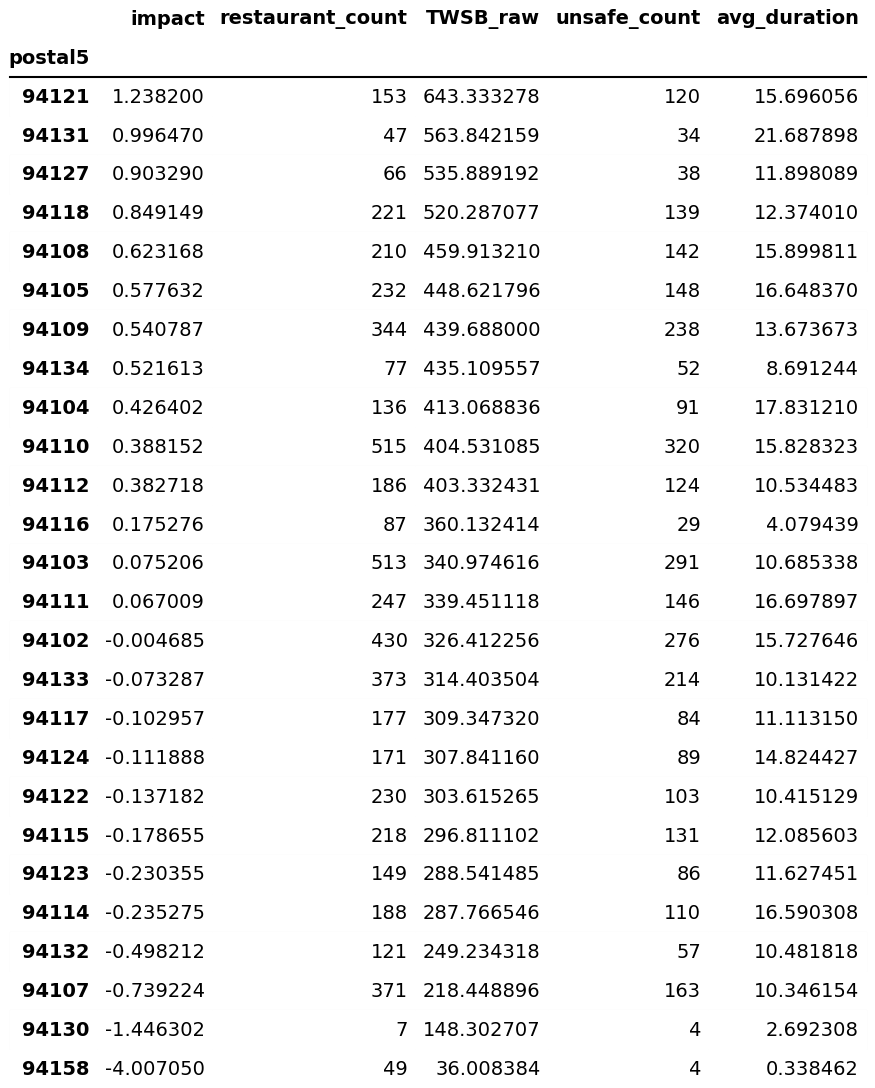

In [31]:
# Run this cell once you're happy with your final_df
# Set image_created = True once you've run this once
image_created = True

# DO NOT EDIT THE CODE BELOW
if not image_created:
    !pip install dataframe_image
    import dataframe_image as dfi
    
    dfi.export(final_df, "final_df.png", table_conversion="matplotlib")

from IPython.display import Image
Image("final_df.png")

In [32]:
# Set commented_out = True once you have commented out all your code from the scratch cells and the final_df cell

commented_out = True

I define *impact* as the **Gaussian-standardized Time-Weighted Severity Burden (TWSB_z)**, which combines violation severity, unsafe duration, and frequency of unsafe events. For each inspection:

$$
U_i = \mathbf{1}\{ \text{day difference}_i > -1 \}
$$

$$
S_i = \max(0, 100 - \text{routine score}_i)
$$

$$
D_i = \max(0, \text{day difference}_i)
$$

The inspection-level risk is:

$$
\text{Risk}_i = U_i \cdot S_i^2 \cdot \log(1 + D_i)
$$

Postal-level impact is:

$$
\text{TWSB}_{postal} = 
\frac{\sum_i \text{Risk}_i}{N_{\text{restaurants}}}
$$

Finally, we standardize:

$$
\text{TWSB}_z =
\frac{\text{TWSB}_{postal} - \mu}{\sigma}
$$

Based on the DataFrame, postal code **94121** has the highest `TWSB_z`, meaning it has the greatest cumulative severity-weighted unsafe exposure relative to the city average. This reflects not just frequent failures, but prolonged and serious violations—where targeted funding could reduce the most public health risk.

A counterargument is that inspection scores may reflect inspector subjectivity rather than true safety differences. However, because this metric also incorporates correction duration, it captures sustained unsafe exposure that is less sensitive to scoring bias, making the recommendation more defensible.


<!-- END QUESTION -->

## Summary of Inspections Data

We have done a lot in this homework! 
 
- Broke down the inspection scores in detail using `groupby` and `pivot_table`.
- Joined the business and inspection data and identified restaurants with the worst ratings.
- Took a deep dive into understanding any trends between an inspection score and reinspection frequency.

Over the course of this 2-part homework, we hope you have become more familiar with `pandas` - in terms of identifying when to use particular functions, how they work, when they can support EDA - as well as with EDA and Data Cleaning, as part of the broader Data Science Lifecycle. These tools will serve you well as a data scientist!

In [33]:
grader.check("q5")

q5 results: All test cases passed!

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## Congratulations! You have finished Homework 2B! ##

Scout say hi :)

<img src = "pics/Scout.PNG" width = "400" class="center">

### Course Content Feedback

If you have any feedback about this assignment or about any of our other weekly, weekly assignments, lectures, or discussions, please fill out the [Course Content Feedback Form](https://forms.gle/4AKg1jycvvPGJ5t67). Your input is valuable in helping us improve the quality and relevance of our content to better meet your needs and expectations!

### Submission Instructions

Below, you will see a cell. Running this cell will automatically generate a zip file with your autograded answers. Once you submit this file to the HW 2B Coding assignment on Pensive, Pensive will automatically submit a PDF file with your written answers to the HW 2B Written assignment. If you run into any issues when running this cell, feel free to check this [section](https://ds100.org/debugging-guide/autograder-gradescope/#why-does-the-last-grader-export-cell-fail-if-all-previous-tests-passed) in the Data 100 Debugging Guide.

**Important**: Please check that your written responses were generated and submitted correctly to the HW 2B Written Assignment.

**You are responsible for ensuring your submission follows our requirements and that the PDF for HW 2B written answers was generated/submitted correctly. We will not be granting regrade requests nor extensions to submissions that don't follow instructions.** If you encounter any difficulties with submission, please don't hesitate to reach out to staff prior to the deadline. 

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

In [34]:
# Save your notebook first, then run this cell to export your submission.
grader.export(run_tests=True)

Running your submission against local test cases...


Your submission received the following results when run against available test cases:

    q1a results: All test cases passed!

    q1b results: All test cases passed!

    q1c results: All test cases passed!

    q2a results: All test cases passed!

    q2b results: All test cases passed!

    q4a results: All test cases passed!

    q4b results: All test cases passed!

    q4c results: All test cases passed!

    q5 results: All test cases passed!
